# Predição de Risco de Diabetes — Projeto Final de Mineração de Dados

**Metodologia:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

**Dataset:** Pima Indians Diabetes Dataset


## 1. Entendimento do Negócio

**Objetivo do cliente/domínio:** Apoiar a triagem preventiva de diabetes tipo 2 a partir de indicadores clínicos simples e de fácil coleta (glicemia, IMC, pressão arterial, idade, histórico de gestações, etc.), permitindo identificar pacientes com risco elevado antes de um diagnóstico formal mais custoso.

**Metas do projeto de mineração:**
- Construir um modelo de classificação capaz de prever se uma paciente apresenta risco de diabetes.
- Priorizar **sensibilidade (recall)** da classe positiva: em contexto de saúde, um falso negativo (não identificar uma paciente de risco) tem custo maior que um falso positivo (exame adicional desnecessário).
- Identificar quais variáveis clínicas mais influenciam o risco, gerando informação interpretável para profissionais de saúde.

**Plano de projeto:** seguir as 6 fases do CRISP-DM — Entendimento do Negócio, Entendimento dos Dados, Preparação dos Dados, Modelagem, Avaliação e Entrega.


## 2. Entendimento dos Dados

### 2.1 Coleta dos dados
Dataset público **Pima Indians Diabetes**, amplamente utilizado como benchmark em mineração de dados na área de saúde. Contém registros de mulheres de pelo menos 21 anos, de descendência Pima (povo indígena norte-americano), com 8 variáveis clínicas preditoras e 1 variável-alvo binária.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

colunas = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv("diabetes.csv", names=colunas)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Descrição das variáveis:**

| Variável | Descrição |
|---|---|
| Pregnancies | Número de gestações |
| Glucose | Concentração de glicose plasmática (teste oral de tolerância à glicose) |
| BloodPressure | Pressão arterial diastólica (mm Hg) |
| SkinThickness | Espessura da dobra cutânea do tríceps (mm) |
| Insulin | Insulina sérica de 2h (mu U/ml) |
| BMI | Índice de massa corporal (kg/m²) |
| DiabetesPedigreeFunction | Função que estima o risco genético/histórico familiar de diabetes |
| Age | Idade (anos) |
| Outcome | Variável-alvo: 1 = diabética, 0 = não diabética |

### 2.2 Análise exploratória dos dados


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64


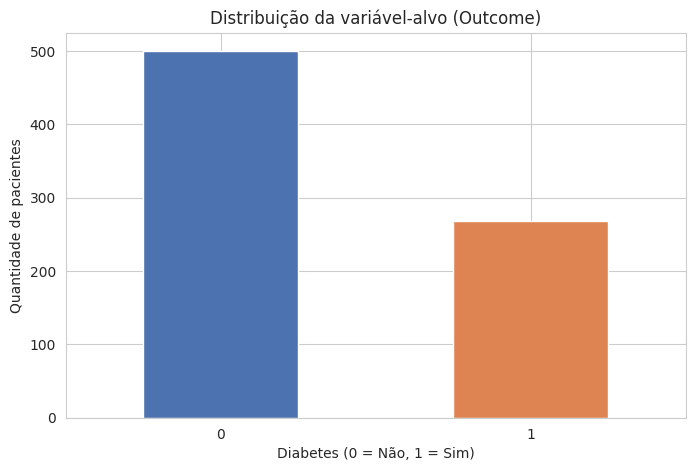


Proporção de diabéticos: 34.9%


In [4]:
# Distribuição da variável-alvo
contagem = df["Outcome"].value_counts()
print(contagem)
contagem.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Distribuição da variável-alvo (Outcome)")
plt.xlabel("Diabetes (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade de pacientes")
plt.xticks(rotation=0)
plt.show()

print(f"\nProporção de diabéticos: {contagem[1] / len(df) * 100:.1f}%")

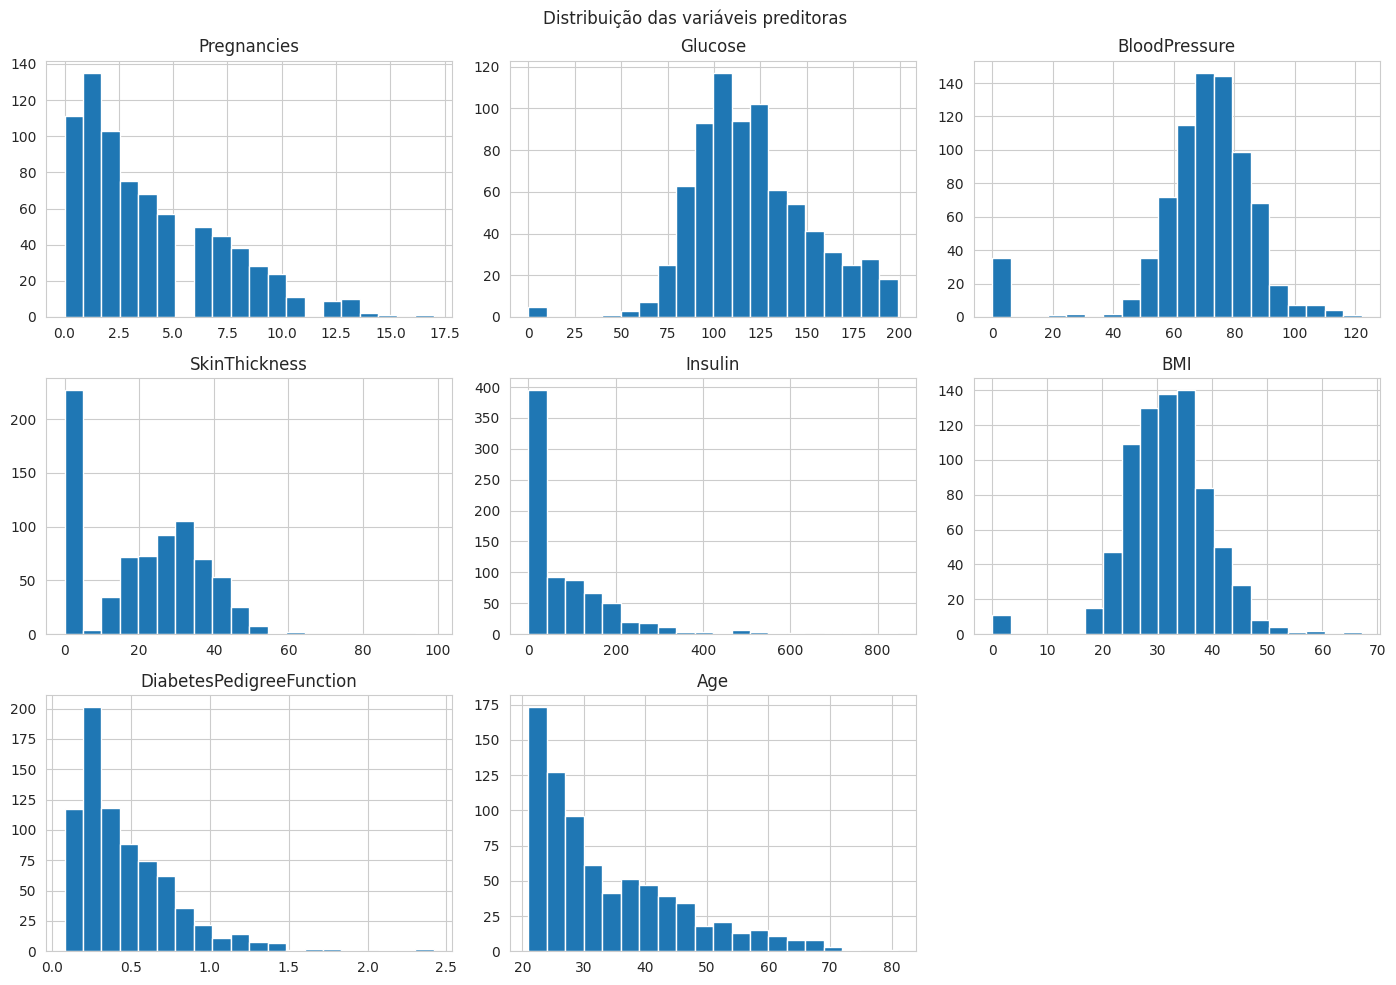

In [5]:
# Distribuições das variáveis preditoras
df.drop(columns="Outcome").hist(bins=20, figsize=(14, 10))
plt.suptitle("Distribuição das variáveis preditoras")
plt.tight_layout()
plt.show()

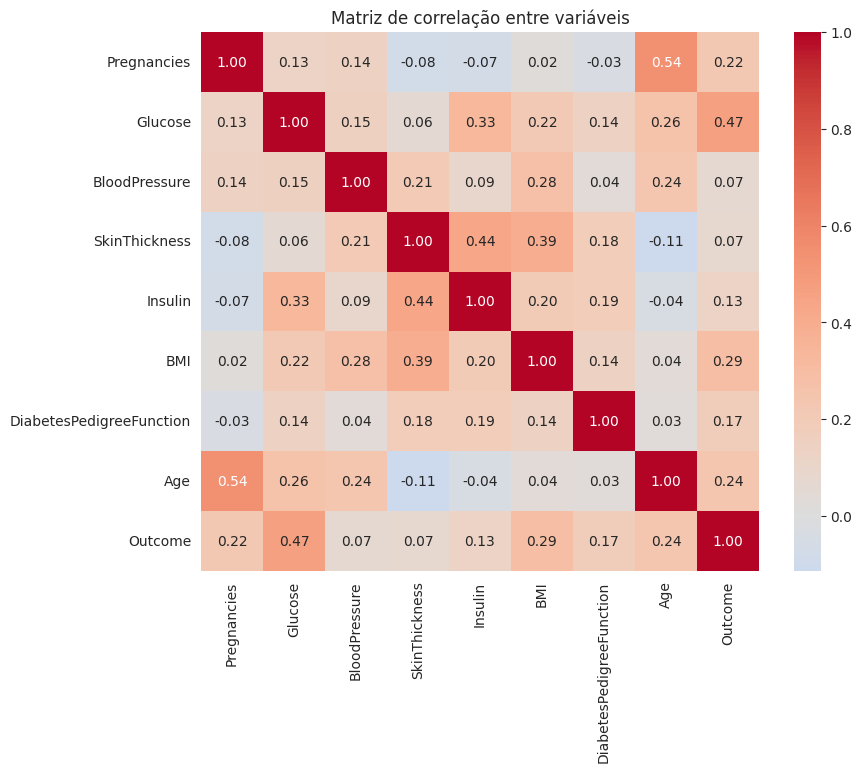

In [6]:
# Matriz de correlação
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação entre variáveis")
plt.show()

### 2.3 Verificação da qualidade dos dados

Um problema conhecido deste dataset: valores **zero** em `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` e `BMI` não fazem sentido fisiológico (não é possível ter glicemia ou IMC igual a zero) — são, na verdade, **dados faltantes disfarçados** de zero.


In [7]:
colunas_zero_invalido = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for c in colunas_zero_invalido:
    n_zeros = (df[c] == 0).sum()
    print(f"{c}: {n_zeros} valores zerados ({n_zeros/len(df)*100:.1f}%)")

Glucose: 5 valores zerados (0.7%)
BloodPressure: 35 valores zerados (4.6%)
SkinThickness: 227 valores zerados (29.6%)
Insulin: 374 valores zerados (48.7%)
BMI: 11 valores zerados (1.4%)


## 3. Preparação dos Dados

### 3.1 Seleção e limpeza dos dados
Os zeros inválidos identificados acima serão tratados como valores ausentes (`NaN`) e depois imputados pela **mediana** de cada variável — escolha mais robusta que a média, pois é menos sensível a outliers.


In [8]:
df_prep = df.copy()

for c in colunas_zero_invalido:
    df_prep[c] = df_prep[c].replace(0, np.nan)

print("Valores ausentes após conversão:")
print(df_prep.isna().sum())

Valores ausentes após conversão:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [9]:
for c in colunas_zero_invalido:
    mediana = df_prep[c].median()
    df_prep[c] = df_prep[c].fillna(mediana)

print("Valores ausentes após imputação pela mediana:")
print(df_prep.isna().sum())

Valores ausentes após imputação pela mediana:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### 3.2 Construção e formatação da base
Separação em variáveis preditoras (X) e variável-alvo (y), divisão em treino/teste e padronização das variáveis numéricas — necessária para modelos sensíveis à escala, como Regressão Logística e KNN.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_prep.drop(columns="Outcome")
y = df_prep["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 576 amostras | Teste: 192 amostras


### 3.3 Descrição da base final
Base final com 768 registros, 8 variáveis preditoras numéricas (sem valores ausentes ou zerados inválidos) e a variável-alvo `Outcome`, dividida em 75% treino / 25% teste, estratificada pela proporção de classes.


## 4. Modelagem

Serão comparados três algoritmos de classificação, escolhidos por complementaridade:
- **Regressão Logística**: modelo interpretável, bom baseline e fácil de justificar clinicamente.
- **Random Forest**: captura relações não-lineares e fornece importância das variáveis.
- **KNN**: modelo simples baseado em similaridade entre pacientes.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
}

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)

print("Modelos treinados:", list(modelos.keys()))

Modelos treinados: ['Regressão Logística', 'Random Forest', 'KNN (k=7)']


## 5. Avaliação

Métricas priorizadas: **recall** (sensibilidade) da classe positiva, além de acurácia, precisão, F1-score e AUC — sempre relacionando os resultados ao objetivo de negócio definido na primeira fase (minimizar falsos negativos).


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

resultados = []

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
    })

resultados_df = pd.DataFrame(resultados).set_index("Modelo").round(3)
resultados_df

,Acurácia,Precisão,Recall,F1-score,AUC
Modelo,,,,,
Regressão Logística,0.729,0.636,0.522,0.574,0.824
Random Forest,0.745,0.661,0.552,0.602,0.809
KNN (k=7),0.724,0.625,0.522,0.569,0.782


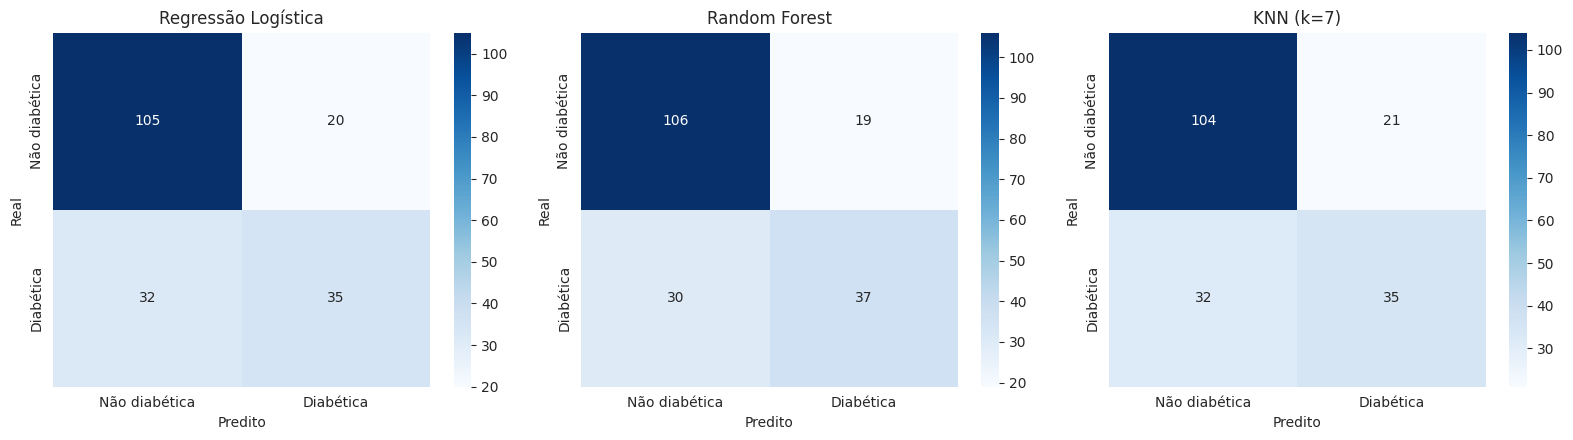

In [13]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nome, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Não diabética", "Diabética"],
                yticklabels=["Não diabética", "Diabética"])
    ax.set_title(nome)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

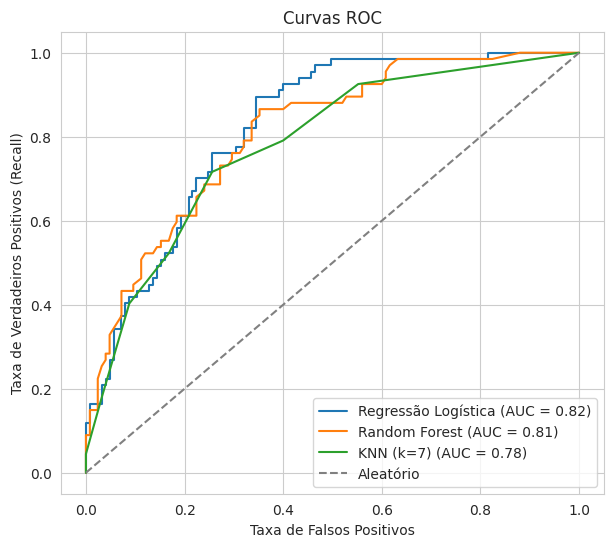

In [14]:
# Curvas ROC
plt.figure(figsize=(7, 6))

for nome, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos (Recall)")
plt.title("Curvas ROC")
plt.legend()
plt.show()

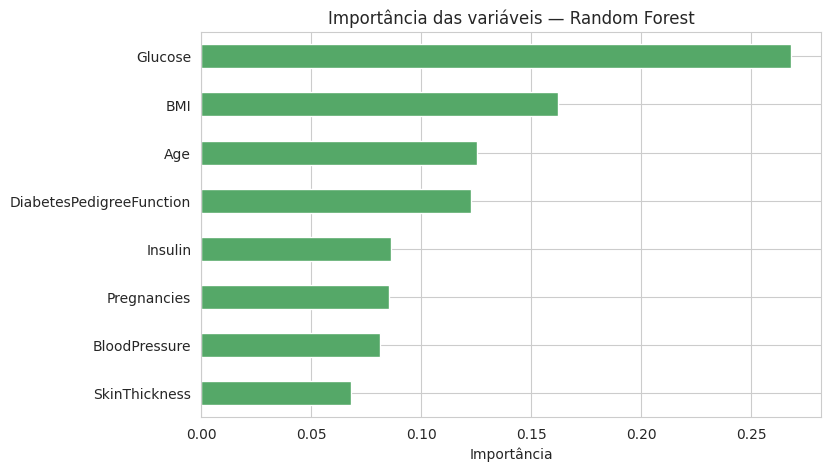

Glucose                     0.268355
BMI                         0.162037
Age                         0.125556
DiabetesPedigreeFunction    0.122838
Insulin                     0.086484
Pregnancies                 0.085242
BloodPressure               0.081218
SkinThickness               0.068270
dtype: float64

In [15]:
# Importância das variáveis (Random Forest)
importancias = pd.Series(
    modelos["Random Forest"].feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importancias.plot(kind="barh", color="#55A868")
plt.title("Importância das variáveis — Random Forest")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.show()

importancias

**Interpretação dos resultados:** *(preencher após rodar o notebook)*
- Qual modelo obteve o melhor recall e por que isso importa neste contexto?
- As variáveis mais importantes (ex.: Glucose, BMI, Age) fazem sentido clínico?
- Os padrões identificados atendem ao objetivo de negócio definido na Fase 1?
- Os resultados foram avaliados sob a ótica de todas as partes interessadas (paciente, profissional de saúde, gestor)?


## 6. Entrega

### 6.1 Relatório de entrega e lições aprendidas
*(a preencher no relatório final)*
- Resumo dos principais resultados e do modelo escolhido para uso prático.
- Limitações do estudo: dataset relativamente pequeno (768 registros) e restrito a uma população específica (mulheres, descendência Pima) — atenção ao viés de amostra ao generalizar para outras populações.
- Lições aprendidas ao longo do processo (tratamento dos zeros disfarçados, comparação de modelos, escolha de métricas).

### 6.2 Planejamento do monitoramento do modelo
- Reavaliar periodicamente o modelo com novos dados clínicos, para detectar *drift* (mudança no padrão dos dados ao longo do tempo).
- Definir um limiar de decisão (threshold) ajustável conforme a política de saúde adotada (priorizando recall ou precisão).
- Estabelecer processo de revisão por profissionais de saúde antes de qualquer uso do modelo em decisões reais.
